In [2]:

!pip install pandas numpy matplotlib

Generated realistic DRS data with 10 deliveries saved to drs_realistic_data.csv

Sample data (first 5 rows):
  delivery_id match_id bowler_id batsman_id ball_type  \
0          D1   M79366        B1        BT9   bouncer   
1          D1   M79366        B1        BT9   bouncer   
2          D1   M79366        B1        BT9   bouncer   
3          D1   M79366        B1        BT9   bouncer   
4          D1   M79366        B1        BT9   bouncer   

                   timestamp      x      y      z  frame_number  \
0 2025-04-23 17:38:37.366631  0.486  2.258  0.009             1   
1 2025-04-23 17:38:37.372394  0.490  2.271  0.200             2   
2 2025-04-23 17:38:37.378157  0.498  2.272  0.416             3   
3 2025-04-23 17:38:37.383920  0.495  2.277  0.606             4   
4 2025-04-23 17:38:37.389682  0.498  2.279  0.809             5   

   is_hawkeye_prediction  hit_stumps  
0                  False       False  
1                  False       False  
2                  False    

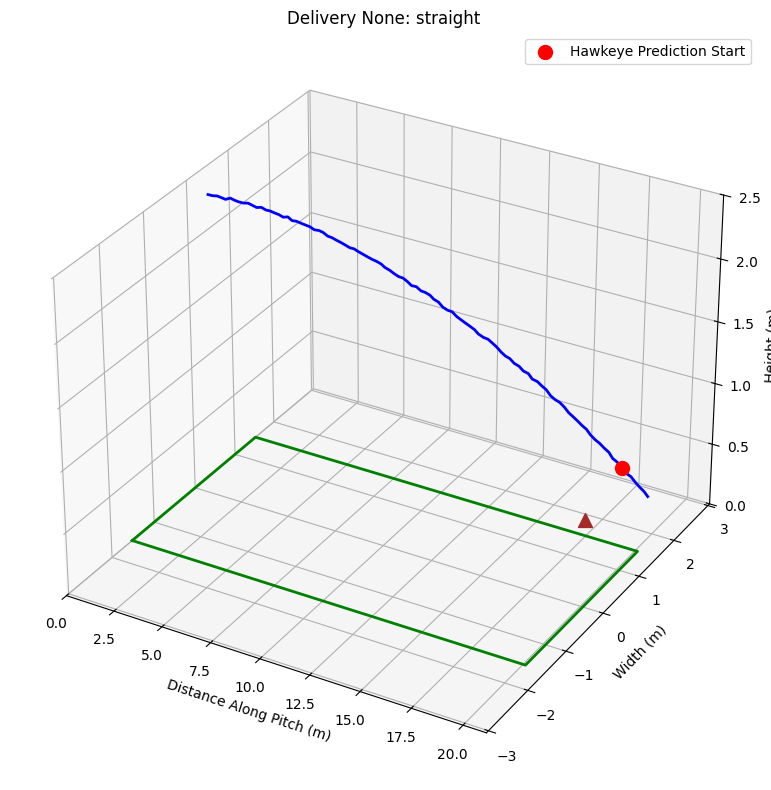

In [5]:
import pandas as pd
import numpy as np
import random
import datetime
import csv
import math


def generate_ball_trajectory(delivery_id, match_id, bowler_id, batsman_id, ball_type=None):
    """
    Generate a realistic cricket ball trajectory based on standard cricket pitch dimensions
    and realistic ball physics including swing, seam, spin, and bounce.

    Standard cricket pitch is 22 yards (20.12 meters) long and 10 feet (3.05 meters) wide.
    Stumps are 28 inches (0.71 meters) high.
    """
    # Standard cricket dimensions in meters
    PITCH_LENGTH = 20.12  # 22 yards
    PITCH_WIDTH = 3.05    # 10 feet
    STUMPS_HEIGHT = 0.71  # 28 inches
    STUMPS_WIDTH = 0.23   # 9 inches total width of three stumps

    # Number of data points for this trajectory (increased for smoother visualization)
    num_points = 100

    # Starting time
    start_time = datetime.datetime.now()

    # Define ball types if not specified
    if not ball_type:
        ball_types = ['inswinger', 'outswinger', 'yorker', 'bouncer', 'googly',
                      'leg-break', 'off-break', 'slower-ball', 'straight']
        ball_type = random.choice(ball_types)

    # Initial position (from bowler's hand)
    # Right-arm bowler is positive x, left-arm is negative x
    is_left_arm = random.random() < 0.3  # 30% chance of left-arm bowler
    bowling_arm_offset = -0.5 if is_left_arm else 0.5

    # Release position
    release_height = random.uniform(1.9, 2.3)  # Height of bowler's release point
    x_start = bowling_arm_offset + random.uniform(-0.1, 0.1)  # Slight variation
    y_start = release_height  # Release height
    z_start = 0.0  # Starting at bowler's end

    # Determine ball speed (in m/s)
    # Fast: 35-40 m/s (126-144 km/h)
    # Medium: 30-35 m/s (108-126 km/h)
    # Spin: 20-30 m/s (72-108 km/h)

    if 'spin' in ball_type or 'break' in ball_type or 'googly' in ball_type:
        speed = random.uniform(20, 30)
    elif 'slower' in ball_type:
        speed = random.uniform(25, 32)
    else:
        speed = random.uniform(30, 40)

    # Total flight time based on speed and pitch length
    flight_time = PITCH_LENGTH / speed
    time_step = flight_time / (num_points - 1)

    # Initial velocity components
    # For a cricket ball, we need to account for the angle of release
    release_angle_horizontal = random.uniform(-5, 5) * (math.pi / 180)  # Convert to radians

    # Different vertical angles based on ball type
    if 'yorker' in ball_type:
        release_angle_vertical = random.uniform(-2, 0) * (math.pi / 180)
    elif 'bouncer' in ball_type:
        release_angle_vertical = random.uniform(0, 5) * (math.pi / 180)
    else:
        release_angle_vertical = random.uniform(-2, 3) * (math.pi / 180)

    v_x = speed * math.sin(release_angle_horizontal)
    v_y = speed * math.sin(release_angle_vertical)
    v_z = speed * math.cos(release_angle_horizontal) * math.cos(release_angle_vertical)

    # Physical parameters
    gravity = 9.81  # m/s²

    # Swing parameters based on ball type
    if 'inswinger' in ball_type:
        swing_direction = 1 if not is_left_arm else -1  # Moves toward the batsman
        swing_magnitude = random.uniform(0.5, 1.2)
    elif 'outswinger' in ball_type:
        swing_direction = -1 if not is_left_arm else 1  # Away from the batsman
        swing_magnitude = random.uniform(0.5, 1.2)
    else:
        swing_direction = random.choice([-1, 1])
        swing_magnitude = random.uniform(0, 0.5)

    # Spin parameters
    spin_effect = 0
    if 'leg-break' in ball_type:
        spin_effect = random.uniform(0.3, 0.8) * (1 if not is_left_arm else -1)
    elif 'off-break' in ball_type or 'googly' in ball_type:
        spin_effect = random.uniform(0.3, 0.8) * (-1 if not is_left_arm else 1)

    # Calculate batsman position (slightly varying)
    batsman_z = PITCH_LENGTH - random.uniform(1.2, 1.5)  # Batsman stands ~1.2-1.5m from stumps

    # Lists to store trajectory data
    timestamps = []
    x_coords = []
    y_coords = []
    z_coords = []

    # Generate points along trajectory
    for i in range(num_points):
        # Current time
        t = i * time_step

        # Position without effects
        z = z_start + v_z * t

        # Add swing effect - most prominent in the middle of the trajectory
        swing_peak = PITCH_LENGTH * 0.6  # Swing peaks at 60% of pitch length
        swing_factor = swing_magnitude * math.exp(-((z - swing_peak) ** 2) / (2 * (PITCH_LENGTH * 0.2) ** 2))

        # Basic movement
        x = x_start + v_x * t + swing_direction * swing_factor
        y = y_start + v_y * t - 0.5 * gravity * t ** 2

        # Add spin effect after bounce
        bounce_point = z < batsman_z and y <= 0.1
        if bounce_point:
            # Calculate point of bounce
            t_bounce = max(0, t - time_step)  # Approximate time of bounce
            spin_effect_strength = spin_effect * (1 - (t_bounce / flight_time))  # Spin diminishes over time
            x += spin_effect_strength * (t - t_bounce)

            # Bounce effect - ball loses energy and changes direction
            # Make sure y doesn't go below 0 (ground level)
            y = max(0.03, abs(y) * 0.6)  # Bounce with energy loss

        # Make sure the ball stays above ground level
        y = max(0.01, y)

        # Add small random variations
        x += random.uniform(-0.01, 0.01)
        y += random.uniform(-0.01, 0.01)
        z += random.uniform(-0.01, 0.01)

        # Calculate timestamp
        timestamp = start_time + datetime.timedelta(seconds=t)

        # Append to lists
        timestamps.append(timestamp)
        x_coords.append(round(x, 3))
        y_coords.append(round(y, 3))
        z_coords.append(round(z, 3))

    # Determine if ball hit stumps or was played by batsman
    final_x = x_coords[-1]
    final_y = y_coords[-1]

    # Check if the ball would hit the stumps
    hit_stumps = (abs(final_x) < STUMPS_WIDTH/2 and final_y < STUMPS_HEIGHT and z_coords[-1] >= PITCH_LENGTH)

    # Create hawkeye prediction flags
    # Typically hawkeye starts predictions after the ball passes the batsman or after impact
    batsman_frame = next((i for i, z in enumerate(z_coords) if z >= batsman_z), num_points-10)
    is_hawkeye_prediction = [i >= batsman_frame for i in range(num_points)]

    # Create a dictionary for this trajectory
    trajectory_data = {
        'delivery_id': [delivery_id] * num_points,
        'match_id': [match_id] * num_points,
        'bowler_id': [bowler_id] * num_points,
        'batsman_id': [batsman_id] * num_points,
        'ball_type': [ball_type] * num_points,
        'timestamp': timestamps,
        'x': x_coords,
        'y': y_coords,
        'z': z_coords,
        'frame_number': list(range(1, num_points + 1)),
        'is_hawkeye_prediction': is_hawkeye_prediction,
        'hit_stumps': [hit_stumps] * num_points
    }

    return trajectory_data


def generate_dummy_drs_data(num_deliveries=10, output_file='drs_realistic_data.csv'):
    """Generate realistic DRS data for multiple deliveries and save to CSV"""
    all_data = {
        'delivery_id': [],
        'match_id': [],
        'bowler_id': [],
        'batsman_id': [],
        'ball_type': [],
        'timestamp': [],
        'x': [],
        'y': [],
        'z': [],
        'frame_number': [],
        'is_hawkeye_prediction': [],
        'hit_stumps': []
    }

    # Create a realistic match scenario
    match_id = f"M{random.randint(10000, 99999)}"

    # Define team rosters for realism
    bowlers = [f"B{i}" for i in range(1, 6)]  # 5 bowlers
    batsmen = [f"BT{i}" for i in range(1, 12)]  # 11 batsmen

    # Ball types with their probabilities
    ball_types = {
        'fast': ['inswinger', 'outswinger', 'yorker', 'bouncer', 'straight'],
        'spin': ['leg-break', 'off-break', 'googly', 'straight', 'slower-ball']
    }

    # Generate several trajectories
    for i in range(1, num_deliveries + 1):
        delivery_id = f"D{i}"

        # Select bowler and determine their style
        bowler_id = random.choice(bowlers)
        bowler_num = int(bowler_id[1:])
        is_spinner = bowler_num > 3  # Bowlers 4-5 are spinners

        # Select ball type based on bowler style
        ball_type = random.choice(ball_types['spin'] if is_spinner else ball_types['fast'])

        # Select batsman
        batsman_id = random.choice(batsmen)

        # Generate trajectory
        trajectory = generate_ball_trajectory(delivery_id, match_id, bowler_id, batsman_id, ball_type)

        # Append to the complete dataset
        for key in all_data.keys():
            all_data[key].extend(trajectory[key])

    # Convert to DataFrame
    df = pd.DataFrame(all_data)

    # Save to CSV
    df.to_csv(output_file, index=False)
    print(f"Generated realistic DRS data with {num_deliveries} deliveries saved to {output_file}")

    # Display a sample of the data
    print("\nSample data (first 5 rows):")
    print(df.head(5))

    # Calculate some statistics for verification
    print("\nData statistics:")
    print(f"Total rows: {len(df)}")
    print(f"Unique deliveries: {df['delivery_id'].nunique()}")
    print(f"Ball types used: {df['ball_type'].unique()}")
    print(f"X coordinate range: {df['x'].min():.2f} to {df['x'].max():.2f}")
    print(f"Y coordinate range: {df['y'].min():.2f} to {df['y'].max():.2f}")
    print(f"Z coordinate range: {df['z'].min():.2f} to {df['z'].max():.2f}")
    print(f"Stumps hit: {df['hit_stumps'].sum() // 100}")  # Divide by points per trajectory


def visualize_trajectory(delivery_id=None, output_file=None):
    """Visualize a ball trajectory for analysis (requires matplotlib)"""
    try:
        import matplotlib.pyplot as plt
        from mpl_toolkits.mplot3d import Axes3D

        # Generate a single trajectory if not visualizing from file
        if not output_file:
            data = generate_ball_trajectory('test', 'test', 'B1', 'BT1')
            df = pd.DataFrame(data)
        else:
            df = pd.read_csv(output_file)
            if delivery_id:
                df = df[df['delivery_id'] == delivery_id]
            else:
                # Just take the first delivery in the file
                delivery_id = df['delivery_id'].iloc[0]
                df = df[df['delivery_id'] == delivery_id]

        # Create 3D plot
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')

        # Plot the trajectory
        ax.plot(df['z'], df['x'], df['y'], 'b-', linewidth=2)

        # Mark the points where hawkeye prediction starts
        hawkeye_start = df[df['is_hawkeye_prediction']].iloc[0]
        ax.scatter([hawkeye_start['z']], [hawkeye_start['x']], [hawkeye_start['y']],
                   color='red', s=100, label='Hawkeye Prediction Start')

        # Draw cricket pitch
        pitch_length = 20.12
        pitch_width = 3.05

        # Draw pitch rectangle
        x_pitch = [-pitch_width/2, -pitch_width/2, pitch_width/2, pitch_width/2, -pitch_width/2]
        z_pitch = [0, pitch_length, pitch_length, 0, 0]
        y_pitch = [0, 0, 0, 0, 0]
        ax.plot(z_pitch, x_pitch, y_pitch, 'g-', linewidth=2)

        # Draw stumps at batsman end
        stumps_height = 0.71
        stumps_width = 0.23
        stumps_x = [0]
        stumps_z = [pitch_length]
        stumps_y = [stumps_height]
        ax.scatter(stumps_z, stumps_x, stumps_y, color='brown', s=100, marker='^')

        # Set axis labels and limits
        ax.set_xlabel('Distance Along Pitch (m)')
        ax.set_ylabel('Width (m)')
        ax.set_zlabel('Height (m)')

        ax.set_xlim(0, pitch_length + 1)
        ax.set_ylim(-pitch_width, pitch_width)
        ax.set_zlim(0, 2.5)

        # Set title
        ball_type = df['ball_type'].iloc[0]
        hit_stumps = df['hit_stumps'].iloc[0]
        title = f"Delivery {delivery_id}: {ball_type}"
        if hit_stumps:
            title += " - Hit Stumps!"
        ax.set_title(title)

        # Add legend
        ax.legend()

        plt.tight_layout()
        plt.show()

    except ImportError:
        print("Matplotlib is required for visualization. Install it with 'pip install matplotlib'")


# Generate dummy data when script is run directly
if __name__ == "__main__":
    # Generate 10 deliveries of realistic cricket data
    generate_dummy_drs_data(num_deliveries=10)

    # Uncomment to visualize a trajectory (requires matplotlib)
    visualize_trajectory()